# Preparation de l'env

In [1]:
!pip install nibabel scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.7 MB/s eta 0:00:00


In [2]:
# 1. On crée le dossier cible
!mkdir -p /content/Data

# 2. On décompresse les deux patients directement dans le dossier Data
!tar -xf /content/BraTS2021_00495.tar -C /content/Data
!tar -xf /content/BraTS2021_00621.tar -C /content/Data

# 3. On affiche le contenu du dossier pour vérifier
!ls /content/Data

BraTS2021_00495_flair.nii.gz  BraTS2021_00621_flair.nii.gz
BraTS2021_00495_seg.nii.gz    BraTS2021_00621_seg.nii.gz
BraTS2021_00495_t1ce.nii.gz   BraTS2021_00621_t1ce.nii.gz
BraTS2021_00495_t1.nii.gz     BraTS2021_00621_t1.nii.gz
BraTS2021_00495_t2.nii.gz     BraTS2021_00621_t2.nii.gz


# Imports et Création du DataLoader

In [3]:
import os
import torch
import nibabel as nib
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# CLASSE DATASET
class BraTSDataset(Dataset):
    def __init__(self, data_dir, target_size=(128, 128)):
        self.data_dir = data_dir
        self.target_size = target_size
        self.file_names = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_names[idx])
        img = nib.load(file_path)
        data = img.get_fdata()

        # Coupe centrale et normalisation Min-Max
        z_mid = data.shape[2] // 2
        slice_2d = data[:, :, z_mid].astype(np.float32)
        if np.max(slice_2d) > 0:
            slice_2d = slice_2d / np.max(slice_2d)

        tensor_img = torch.tensor(slice_2d).unsqueeze(0)
        tensor_img = F.interpolate(tensor_img.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)

        return tensor_img, tensor_img

# INITIALISATION DU DATALOADER
path_to_data = '/content/Data'
os.makedirs(path_to_data, exist_ok=True)
dataset = BraTSDataset(data_dir=path_to_data)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"Prêt ! {len(dataset)} images chargées.")

Prêt ! 10 images chargées.


# Architecture du Model

In [4]:
class BraTSAutoencoder(nn.Module):
    def __init__(self):
        super(BraTSAutoencoder, self).__init__()

        # Encodeur
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU()
        )

        # Embedding  taille 256
        self.flatten = nn.Flatten()
        self.embedding_layer = nn.Linear(64 * 16 * 16, 256)

        # Decodeur
        self.unflatten = nn.Linear(256, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        x_encoded = self.flatten(self.encoder(x))
        embedding = self.embedding_layer(x_encoded)
        reconstruction = self.decoder(self.unflatten(embedding).view(-1, 64, 16, 16))
        return reconstruction, embedding

# Train & save

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BraTSAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20

print("--- DEBUT DU TRAIN---")
model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for batch_images, batch_targets in train_loader:
        batch_images, batch_targets = batch_images.to(device), batch_targets.to(device)

        optimizer.zero_grad()
        reconstructions, _ = model(batch_images)
        loss = criterion(reconstructions, batch_targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / max(1, len(train_loader))
    print(f"Epoque [{epoch+1}/{epochs}] - MSE Loss : {avg_loss:.6f}")

# Sauvegarde des poids
torch.save(model.state_dict(), 'modele_encodeur_brats.pth')
print("--- MODEL SAVED ---")

--- DEBUT DU TRAIN---
Epoque [1/20] - MSE Loss : 0.259162
Epoque [2/20] - MSE Loss : 0.257867
Epoque [3/20] - MSE Loss : 0.253923
Epoque [4/20] - MSE Loss : 0.244533
Epoque [5/20] - MSE Loss : 0.225030
Epoque [6/20] - MSE Loss : 0.194045
Epoque [7/20] - MSE Loss : 0.159764
Epoque [8/20] - MSE Loss : 0.130297
Epoque [9/20] - MSE Loss : 0.106034
Epoque [10/20] - MSE Loss : 0.084079
Epoque [11/20] - MSE Loss : 0.065356
Epoque [12/20] - MSE Loss : 0.052735
Epoque [13/20] - MSE Loss : 0.045073
Epoque [14/20] - MSE Loss : 0.040331
Epoque [15/20] - MSE Loss : 0.036809
Epoque [16/20] - MSE Loss : 0.034263
Epoque [17/20] - MSE Loss : 0.032354
Epoque [18/20] - MSE Loss : 0.030817
Epoque [19/20] - MSE Loss : 0.029774
Epoque [20/20] - MSE Loss : 0.028861
--- MODEL SAVED ---


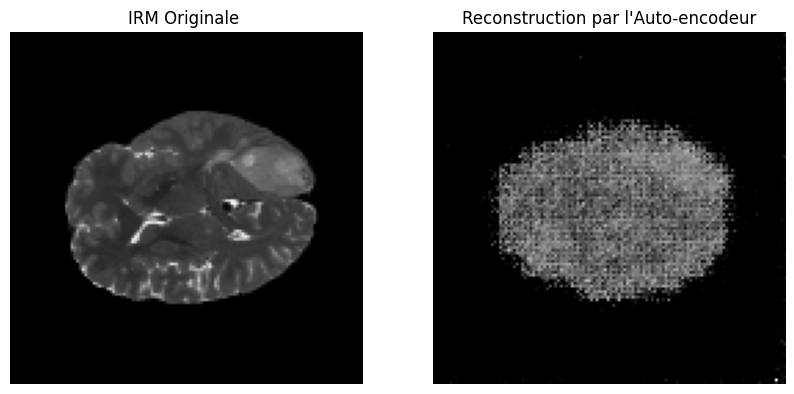

In [7]:
import matplotlib.pyplot as plt

model.eval()


images, _ = next(iter(train_loader))
images = images.to(device)


with torch.no_grad():
    reconstructions, embeddings = model(images)

img_originale = images[0].cpu().squeeze().numpy()
img_reconstruite = reconstructions[0].cpu().squeeze().numpy()

# Affichage
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("IRM Originale ")
plt.imshow(img_originale, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstruction par l'Auto-encodeur")
plt.imshow(img_reconstruite, cmap='gray')
plt.axis('off')

plt.show()